# Задачи к Лекции 2

__Исходные данные__

Дан файл **"mlbootcamp5_train.csv"**. В нем содержатся данные об опросе 70000 пациентов с целью определения наличия заболеваний сердечно-сосудистой системы (ССЗ). Данные в файле промаркированы и если у человека имееются ССЗ, то значение **cardio** будет равно 1, в противном случае - 0. Описание и значения полей представлены во второй лекции.

__Загрузка файла__

In [5]:
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/content/mlbootcamp5_train.csv",
                 sep=";",
                 index_col="id")
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
id,,,,,,,,,,,,
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Задачи

**1. Построить наивный байесовский классификатор для количественных полей age, height, weight, ap_hi, ap_lo. Исправить данные, если это необходимо. Привести матрицу неточностей и сравнить со значением полученным в ходе лекции. Попытаться объяснить разницу.**

In [ ]:
#подготовка данных
features = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
target = 'cardio'

#судя по всему возраст указан в днях, приведем к виду в годах
df['age'] = (df['age'] * 365).round(2)

#уберем явные аутлаеры
df_clean = df[
    (df['height'] >= 120) &
    (df['height'] <= 220) &
    (df['weight'] >= 30) &
    (df['weight'] <= 200) &
    (df['ap_hi'] >= 80) &
    (df['ap_hi'] <= 200) &
    (df['ap_lo'] >= 40) &
    (df['ap_lo'] <= 150) &
    (df['ap_hi'] >= df['ap_lo'])
].copy()

print(df_clean.shape, 'осталось записей после очистки')

(68557, 12) осталось записей после очистки


In [ ]:
#Делим данные на трейн и тест выборки, заодно с пом. random.permutation решаем
#проблему того, что данные нужны из разных частей выборки
X = df_clean[features]
y = df_clean[target]

np.random.seed(42)

indices = np.random.permutation(len(df_clean))

train_size = int(0.7 * len(df_clean))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]

y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

In [ ]:
#вычисляем параметры распределения признаков — среднее (mean) и дисперсию (var).

def calculate_parameters(X_train, y_train):
    parameters = {}

    for class_value in [0, 1]:
        X_class = X_train[y_train == class_value]

        parameters[class_value] = {
            'mean': X_class.mean(),
            'var': X_class.var()
        }

    return parameters


parameters = calculate_parameters(X_train, y_train)

parameters[0]['mean']

,0
age,54.898490
height,164.306380
weight,76.670457
ap_hi,133.727143
ap_lo,84.444051


In [ ]:
#считаем априорные вероятности классов
priors = {}

for class_value in [0, 1]:
    priors[class_value] = np.mean(y_train == class_value)

priors

{0: np.float64(0.5051991081289462), 1: np.float64(0.4948008918710538)}

In [ ]:
def gaussian_probability(x, mean, variance):
    eps = 1e-9

    coefficient = 1 / np.sqrt(2 * np.pi * (variance + eps))

    exponent = np.exp(
        -((x - mean) ** 2) / (2 * (variance + eps))
    )

    return coefficient * exponent

In [ ]:
def calculate_class_probability(row, class_value, parameters, priors):

    probability = priors[class_value]

    means = parameters[class_value]['mean']
    variances = parameters[class_value]['var']

    for feature in features:
        probability *= gaussian_probability(
            row[feature],
            means[feature],
            variances[feature]
        )

    return probability

In [ ]:
def predict(row, parameters, priors):

    probability_0 = calculate_class_probability(
        row,
        0,
        parameters,
        priors
    )

    probability_1 = calculate_class_probability(
        row,
        1,
        parameters,
        priors
    )

    if probability_1 > probability_0:
        return 1
    else:
        return 0

In [ ]:
y_pred = X_test.apply(
    lambda row: predict(row, parameters, priors),
    axis=1
)

In [ ]:
#считаем accuracy
accuracy = np.mean(y_pred.values == y_test.values)

print('Accuracy:', accuracy)

Accuracy: 0.7161124076234928


In [ ]:
#считаем матрицу неточностей
def confusion_matrix_manual(y_true, y_pred):

    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    return np.array([
        [tn, fp],
        [fn, tp]
    ])



In [ ]:
    cm = confusion_matrix_manual(
    y_test.values,
    y_pred.values
)

print(cm)

[[8642 1770]
 [4069 6087]]


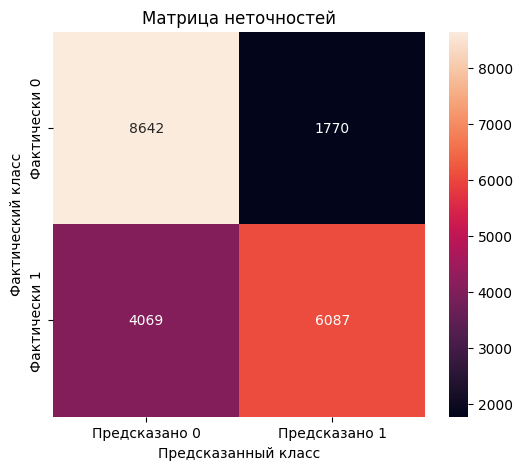

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Предсказано 0', 'Предсказано 1'],
    yticklabels=['Фактически 0', 'Фактически 1']
)

plt.xlabel('Предсказанный класс')
plt.ylabel('Фактический класс')
plt.title('Матрица неточностей')

plt.show()

**Комментарии:** Ваши комментарии здесь.

**2. Написать свой наивный байесовский классификатор для категориальных полей cholesterol, gluc. Привести матрицу неточностей и сравнить со значениями из задачи 1 (нельзя использовать готовое решение из sklearn) (не обязательно)**

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
# Your code here

features = ['cholesterol', 'gluc']
target = 'cardio'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

model = CategoricalNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print('Матрица неточностей:')
print(cm)
print('Accuracy:', accuracy_score(y_test, y_pred))

Матрица неточностей:
[[8208 2253]
 [6418 4121]]
Accuracy: 0.5870952380952381



TN: 8208
FP: 2253
FN: 6418
TP: 4121


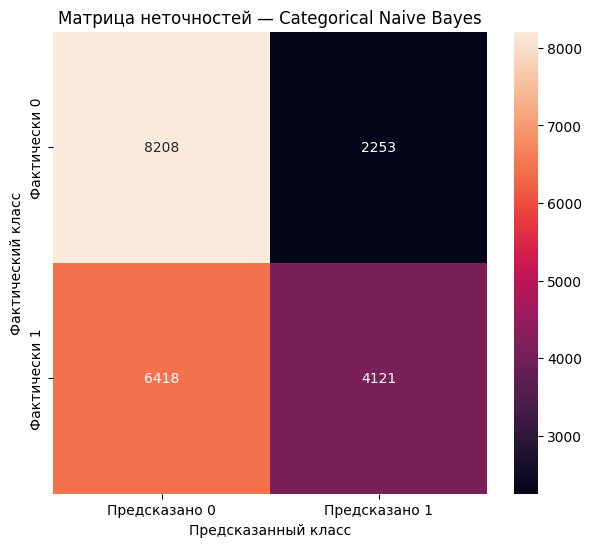

In [10]:
tn = cm[0, 0]
fp = cm[0, 1]
fn = cm[1, 0]
tp = cm[1, 1]

print('\nTN:', tn)
print('FP:', fp)
print('FN:', fn)
print('TP:', tp)


plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=[
        'Предсказано 0',
        'Предсказано 1'
    ],
    yticklabels=[
        'Фактически 0',
        'Фактически 1'
    ]
)

plt.xlabel('Предсказанный класс')
plt.ylabel('Фактический класс')
plt.title(
    'Матрица неточностей — '
    'Categorical Naive Bayes'
)

plt.show()

**Комментарии:** Ваши комментарии здесь.

**3. Построить наивный байесовский классификатор для бинарных полей gender, smoke, alco, active. Привести матрицу неточностей и сравнить с предыдущими значениями.**

In [ ]:
# Your code here

features = ['gender', 'smoke', 'alco', 'active'] #бинарные признаки
target = 'cardio'

X = df[features]
y = df[target]

df['gender'] = df['gender'] - 1 #в таблице гендер принимает значения 1 и 2,
                                #а остальные бинарные значения - 0 и 1

In [ ]:
#Делим данные на трейн и тест выборки, заодно с пом. random.permutation решаем
#проблему того, что данные нужны из разных частей выборки
np.random.seed(42)

indices = np.random.permutation(len(df))

train_size = int(0.7 * len(df))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]

y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

In [ ]:
def calculate_parameters(X_train, y_train):
    parameters = {}

    for class_value in [0, 1]:
        X_class = X_train[y_train == class_value]

        parameters[class_value] = {}

        for feature in features:
            probability_1 = np.mean(
                X_class[feature] == 1
            )

            parameters[class_value][feature] = probability_1

    return parameters

In [ ]:
parameters = calculate_parameters(
    X_train,
    y_train
)

for class_value in [0, 1]:
    print(f'\ncardio = {class_value}')

    for feature in features:
        p1 = parameters[class_value][feature]
        p0 = 1 - p1

        print(
            f'{feature}: '
            f'P(0) = {p0:.4f}, '
            f'P(1) = {p1:.4f}'
        )


cardio = 0
gender: P(0) = 0.3444, P(1) = 0.6556
smoke: P(0) = 0.9086, P(1) = 0.0914
alco: P(0) = 0.9453, P(1) = 0.0547
active: P(0) = 0.1813, P(1) = 0.8187

cardio = 1
gender: P(0) = 0.3538, P(1) = 0.6462
smoke: P(0) = 0.9173, P(1) = 0.0827
alco: P(0) = 0.9477, P(1) = 0.0523
active: P(0) = 0.2099, P(1) = 0.7901


In [ ]:
priors = {}

for class_value in [0, 1]:
    priors[class_value] = np.mean(
        y_train == class_value
    )

print(priors)

{0: np.float64(0.4989795918367347), 1: np.float64(0.5010204081632653)}


In [ ]:
def feature_probability(value, probability_1):

    if value == 1:
        return probability_1

    else:
        return 1 - probability_1

In [ ]:
def calculate_probability(row, class_value, parameters, priors):

    probability = priors[class_value]

    for feature in features:

        probability_1 = parameters[class_value][feature]

        probability *= feature_probability(
            row[feature],
            probability_1
        )

    return probability


def predict(row, parameters, priors):

    probability_0 = calculate_probability(
        row,
        0,
        parameters,
        priors
    )

    probability_1 = calculate_probability(
        row,
        1,
        parameters,
        priors
    )

    if probability_1 > probability_0:
        return 1
    else:
        return 0

In [ ]:
y_pred = X_test.apply(
    lambda row: predict(
        row,
        parameters,
        priors
    ),
    axis=1
)

In [ ]:
accuracy = np.mean(
    y_pred.values == y_test.values
)

print('Accuracy:', round(accuracy * 100, 2))

Accuracy: 51.65


In [ ]:
def confusion_matrix_manual(y_true, y_pred):

    tn = np.sum(
        (y_true == 0) &
        (y_pred == 0)
    )

    fp = np.sum(
        (y_true == 0) &
        (y_pred == 1)
    )

    fn = np.sum(
        (y_true == 1) &
        (y_pred == 0)
    )

    tp = np.sum(
        (y_true == 1) &
        (y_pred == 1)
    )

    return np.array([
        [tn, fp],
        [fn, tp]
    ])

In [ ]:
cm = confusion_matrix_manual(
    y_test.values,
    y_pred.values
)

print(cm)

[[6467 4104]
 [6050 4379]]


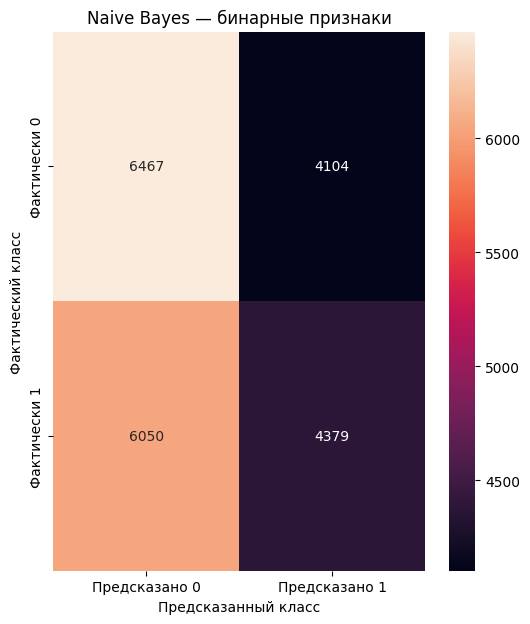

In [ ]:
plt.figure(figsize=(6, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=[
        'Предсказано 0',
        'Предсказано 1'
    ],
    yticklabels=[
        'Фактически 0',
        'Фактически 1'
    ]
)

plt.xlabel('Предсказанный класс')
plt.ylabel('Фактический класс')
plt.title(
    'Naive Bayes — бинарные признаки'
)

plt.show()

**Комментарии:** Ваши комментарии здесь.

**4. К этому моменту у вас есть три независимых классификатора: по количественным полям, категориальным и бинарным. Придумать, как их объединить в один единый классификатор, который учитывает все эти поля. Привести матрицу неточностей для него и сравнить с предыдущими значениями. Попытаться объяснить разницу.**

In [25]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, CategoricalNB

In [ ]:
#подготовка данных
df['age'] = df['age'] / 365

df = df[
    (df['height'] >= 120) &
    (df['height'] <= 220) &
    (df['weight'] >= 30) &
    (df['weight'] <= 200) &
    (df['ap_hi'] >= 80) &
    (df['ap_hi'] <= 200) &
    (df['ap_lo'] >= 40) &
    (df['ap_lo'] <= 150) &
    (df['ap_hi'] >= df['ap_lo'])
].copy()

print('Размер после очистки:', df.shape, df.head)

In [16]:
quant_features = [
    'age',
    'height',
    'weight',
    'ap_hi',
    'ap_lo'
]

binary_features = [
    'gender',
    'smoke',
    'alco',
    'active'
]

categorical_features = [
    'cholesterol',
    'gluc'
]

target = 'cardio'

In [17]:
#гендер имеет значение 1 и 2 в отличие от остальных 0 и 1
df['gender'] = df['gender'] - 1

In [18]:
# cholesterol и gluc имеют значения 1, 2, 3.
# CategoricalNB удобнее использовать с категориями 0, 1, 2.

df['cholesterol'] = df['cholesterol'] - 1
df['gluc'] = df['gluc'] - 1


In [19]:
#разбиение на тест и трейн
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print('\nРазмер train:', X_train.shape)
print('Размер test:', X_test.shape)



Размер train: (47989, 11)
Размер test: (20568, 11)


In [20]:
#разным классификаторам нужны разные признаки
X_quant_train = X_train[quant_features]
X_quant_test = X_test[quant_features]

X_binary_train = X_train[binary_features]
X_binary_test = X_test[binary_features]

X_cat_train = X_train[categorical_features]
X_cat_test = X_test[categorical_features]

In [26]:
quant_model = GaussianNB()

quant_model.fit(
    X_quant_train,
    y_train
)

y_pred_quant = quant_model.predict(X_quant_test)

accuracy_quant = accuracy_score(
    y_test,
    y_pred_quant
)

cm_quant = confusion_matrix(
    y_test,
    y_pred_quant
)


print('Количественные поля')

print('Accuracy:', accuracy_quant)
print('Матрица неточностей:')
print(cm_quant)

Количественные поля
Accuracy: 0.7099377674056787
Матрица неточностей:
[[8509 1888]
 [4078 6093]]


In [27]:
binary_model = BernoulliNB()

binary_model.fit(
    X_binary_train,
    y_train
)

y_pred_binary = binary_model.predict(X_binary_test)

accuracy_binary = accuracy_score(
    y_test,
    y_pred_binary
)

cm_binary = confusion_matrix(
    y_test,
    y_pred_binary
)

print('Бинарные поля')

print('Accuracy:', accuracy_binary)
print('Матрица неточностей:')
print(cm_binary)


Бинарные поля
Accuracy: 0.5181835861532478
Матрица неточностей:
[[8483 1914]
 [7996 2175]]


In [28]:
categorical_model = CategoricalNB()

categorical_model.fit(
    X_cat_train,
    y_train
)

y_pred_cat = categorical_model.predict(X_cat_test)

accuracy_cat = accuracy_score(
    y_test,
    y_pred_cat
)

cm_cat = confusion_matrix(
    y_test,
    y_pred_cat
)

print('Категориальные поля')

print('Accuracy:', accuracy_cat)
print('Матрица неточностей:')
print(cm_cat)


Категориальные поля
Accuracy: 0.5917444574095683
Матрица неточностей:
[[8148 2249]
 [6148 4023]]


In [31]:
#объединение 3 классификаторов
predictions = pd.DataFrame({
    'quantitative': y_pred_quant,
    'binary': y_pred_binary,
    'categorical': y_pred_cat
})


In [32]:
#если 2 или 3 классификатора выбрали данный класс, то будет он; если 0 или 1, то иной
y_pred_final = (
    predictions.sum(axis=1) >= 2
).astype(int)

In [34]:
accuracy_final = accuracy_score(
    y_test,
    y_pred_final
)

cm_final = confusion_matrix(
    y_test,
    y_pred_final
)


print('ОБЪЕДИНЁННЫЙ КЛАССИФИКАТОР')

print('Accuracy:', accuracy_final)

print('\nМатрица неточностей:')
print(cm_final)

ОБЪЕДИНЁННЫЙ КЛАССИФИКАТОР
Accuracy: 0.6267016725009724

Матрица неточностей:
[[9162 1235]
 [6443 3728]]


In [35]:
tn, fp, fn, tp = cm_final.ravel()

print('\nTN:', tn)
print('FP:', fp)
print('FN:', fn)
print('TP:', tp)



TN: 9162
FP: 1235
FN: 6443
TP: 3728


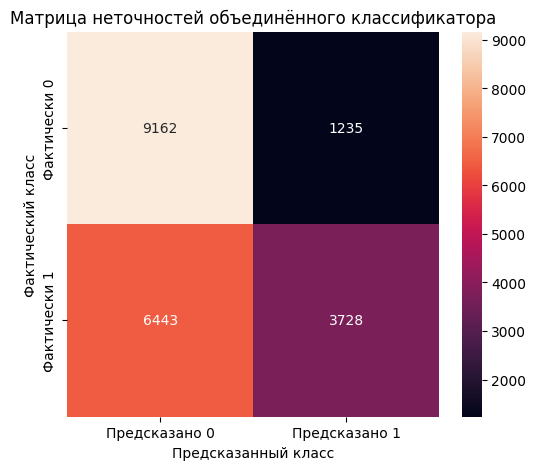

In [36]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    xticklabels=['Предсказано 0', 'Предсказано 1'],
    yticklabels=['Фактически 0', 'Фактически 1']
)

plt.xlabel('Предсказанный класс')
plt.ylabel('Фактический класс')
plt.title('Матрица неточностей объединённого классификатора')

plt.show()